In [1]:
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent

import pandas as pd

pd.set_option('display.max_columns', None)  # none은 제한값 자리(몇개 열까지 보여줄까)
pd.set_option('display.max_rows', None)

# ============================================================
# 1. 데이터 불러오기
# ============================================================

df = pd.read_parquet(PROJECT_ROOT / 'parqueted_data' / 'train.parquet')

# 해당 df의 메모리사용량 확인용
# df.memory_usage(deep=True).sum() / 1024**3

In [2]:
# 메모리 사용 중 객체 불러오기
%whos

Variable       Type           Data/Info
---------------------------------------
PROJECT_ROOT   WindowsPath    c:\Users\20162180\AI_Data_exhibition
Path           type           <class 'pathlib.Path'>
df             DataFrame      Shape: (749657, 25)
pd             module         <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>


In [3]:
# ============================================================
# 2. 컬럼 분리
# ============================================================

# 시계열 컬럼군
time_cols = [
    'wl_t',          # 수위데이터 대표
    'sfc_rain_1h',   # 육상 누적강수데이터 대표
    'imerg_rain_1h', # 레이더 누적강수데이터 대표
    'radar_reflectivity_mean', # 레이더반사도 대표
    'radar_reflectivity_p95', # 레이더반사도 대표
    'target_maxrise_6h' # 종속변수: 수위상승량
]

# 수위 컬럼군
wl_cols_EDA = [  # wl_cols_EDA에는 편의상 종속변수 포함(모델링에서는 필히 제외)
    'wl_t',
    'wl_t_minus_1h',
    'wl_t_minus_3h',
    'wl_t_minus_6h',
    'wl_t_minus_12h',
    'wl_t_minus_24h',
    'target_maxrise_6h',
]

# 강수 컬럼군
rain_cols = [
    # IMERG강우
    'imerg_rain_1h',
    'imerg_rain_6h',
    'imerg_rain_24h',
    # 지상강우
    'sfc_rain_1h',
    'sfc_rain_6h',
    'sfc_rain_24h',
    # 레이더 반사도
    'radar_reflectivity_mean',
    'radar_reflectivity_p95',
    'radar_reflectivity_ge20_fraction'
]

# 환경 컬럼군
env_cols = [
    'cat_area',       # km²
    'wsarea',         # km²
    'mean_elevation', # m
    'mean_slope',     # °
    'urban_ratio',    # %
    'forest_ratio',   # %
    'stream_order'
]

In [4]:
# ============================================================
# 1. EDA 기본: 컬럼별 자료형, 구조 확인
# ============================================================
# 데이터 크기(shape), 컬럼명, 자료형 확인
# print(f"데이터 크기: {df.shape}")
print()
print("<자료형>")
display(df.dtypes)  # row_id, station_id만 object, 나머지는 수치형
print()

# 데이터 일부(head) 확인
# display(df.head())
print()

# 기술통계(describe) 확인: 결과는 #1
df_describe = df.describe(include = 'all')  # include = 'all'은 비수치형자료도 포함 의미
display(df_describe.loc[['mean', '50%', 'max', 'min']])


# mean >> 50%(median)인 변수가 많음, 시각화 필요
skew = df.select_dtypes(include = 'number').skew().sort_values(ascending = False)
print(skew)  # 왜도는 양수면 우측꼬리 긴 우편향, 절대값 > 1부터는 왜도가 있다고 봄



<자료형>


timestamp                           datetime64[us]
station_id                                     str
wl_t                                       float64
wl_t_minus_1h                              float64
wl_t_minus_3h                              float64
wl_t_minus_6h                              float64
wl_t_minus_12h                             float64
wl_t_minus_24h                             float64
imerg_rain_1h                              float64
imerg_rain_6h                              float64
imerg_rain_24h                             float64
sfc_rain_1h                                float64
sfc_rain_6h                                float64
sfc_rain_24h                               float64
radar_reflectivity_mean                    float64
radar_reflectivity_p95                     float64
radar_reflectivity_ge20_fraction           float64
cat_area                                   float64
wsarea                                     float64
mean_elevation                 

,timestamp,station_id,wl_t,wl_t_minus_1h,wl_t_minus_3h,wl_t_minus_6h,wl_t_minus_12h,wl_t_minus_24h,imerg_rain_1h,imerg_rain_6h,imerg_rain_24h,sfc_rain_1h,sfc_rain_6h,sfc_rain_24h,radar_reflectivity_mean,radar_reflectivity_p95,radar_reflectivity_ge20_fraction,cat_area,wsarea,mean_elevation,mean_slope,urban_ratio,forest_ratio,stream_order,target_maxrise_6h
mean,2102-04-11 01:45:19.070721,NaN,4.059135,4.051839,4.03883,4.023965,4.008545,3.995167,1.396494,7.597034,18.236092,1.194352,6.126236,14.769041,13.484527,19.832657,0.340483,3.959319,860.877941,175.267262,12.051279,11.887195,59.067451,2.174168,0.108976
50%,2102-06-10 15:00:00,NaN,1.130000,1.120000,1.11000,1.100000,1.080000,1.060000,0.227000,2.541000,7.629000,0.000000,0.500000,2.500000,13.035000,21.970000,0.111300,3.382800,115.295800,139.300000,11.794400,6.547500,61.066100,2.083300,0.010000
max,2104-02-20 13:00:00,NaN,139.640000,139.690000,139.75000,139.900000,140.140000,140.580000,114.530000,313.557000,371.228000,87.000000,290.500000,390.000000,55.917000,67.770000,1.000000,50.652700,29687.691600,912.520000,24.617200,73.156800,98.361000,7.000000,8.300000
min,2100-01-01 00:00:00,NaN,-3.840000,-3.900000,-3.90000,-3.810000,-3.910000,-3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.260300,5.751600,15.350000,2.946600,0.000000,4.784300,1.000000,-8.740000


cat_area                            11.674061
target_maxrise_6h                    7.332652
wsarea                               7.026063
sfc_rain_1h                          6.625834
wl_t                                 6.338164
wl_t_minus_1h                        6.338152
wl_t_minus_3h                        6.337994
wl_t_minus_6h                        6.337560
wl_t_minus_12h                       6.336212
wl_t_minus_24h                       6.333832
imerg_rain_1h                        5.861829
sfc_rain_6h                          4.293599
imerg_rain_6h                        3.609822
sfc_rain_24h                         3.265063
imerg_rain_24h                       3.150811
stream_order                         2.749272
mean_elevation                       2.124720
urban_ratio                          1.902671
radar_reflectivity_ge20_fraction     0.700954
radar_reflectivity_mean              0.378107
mean_slope                           0.265007
radar_reflectivity_p95            

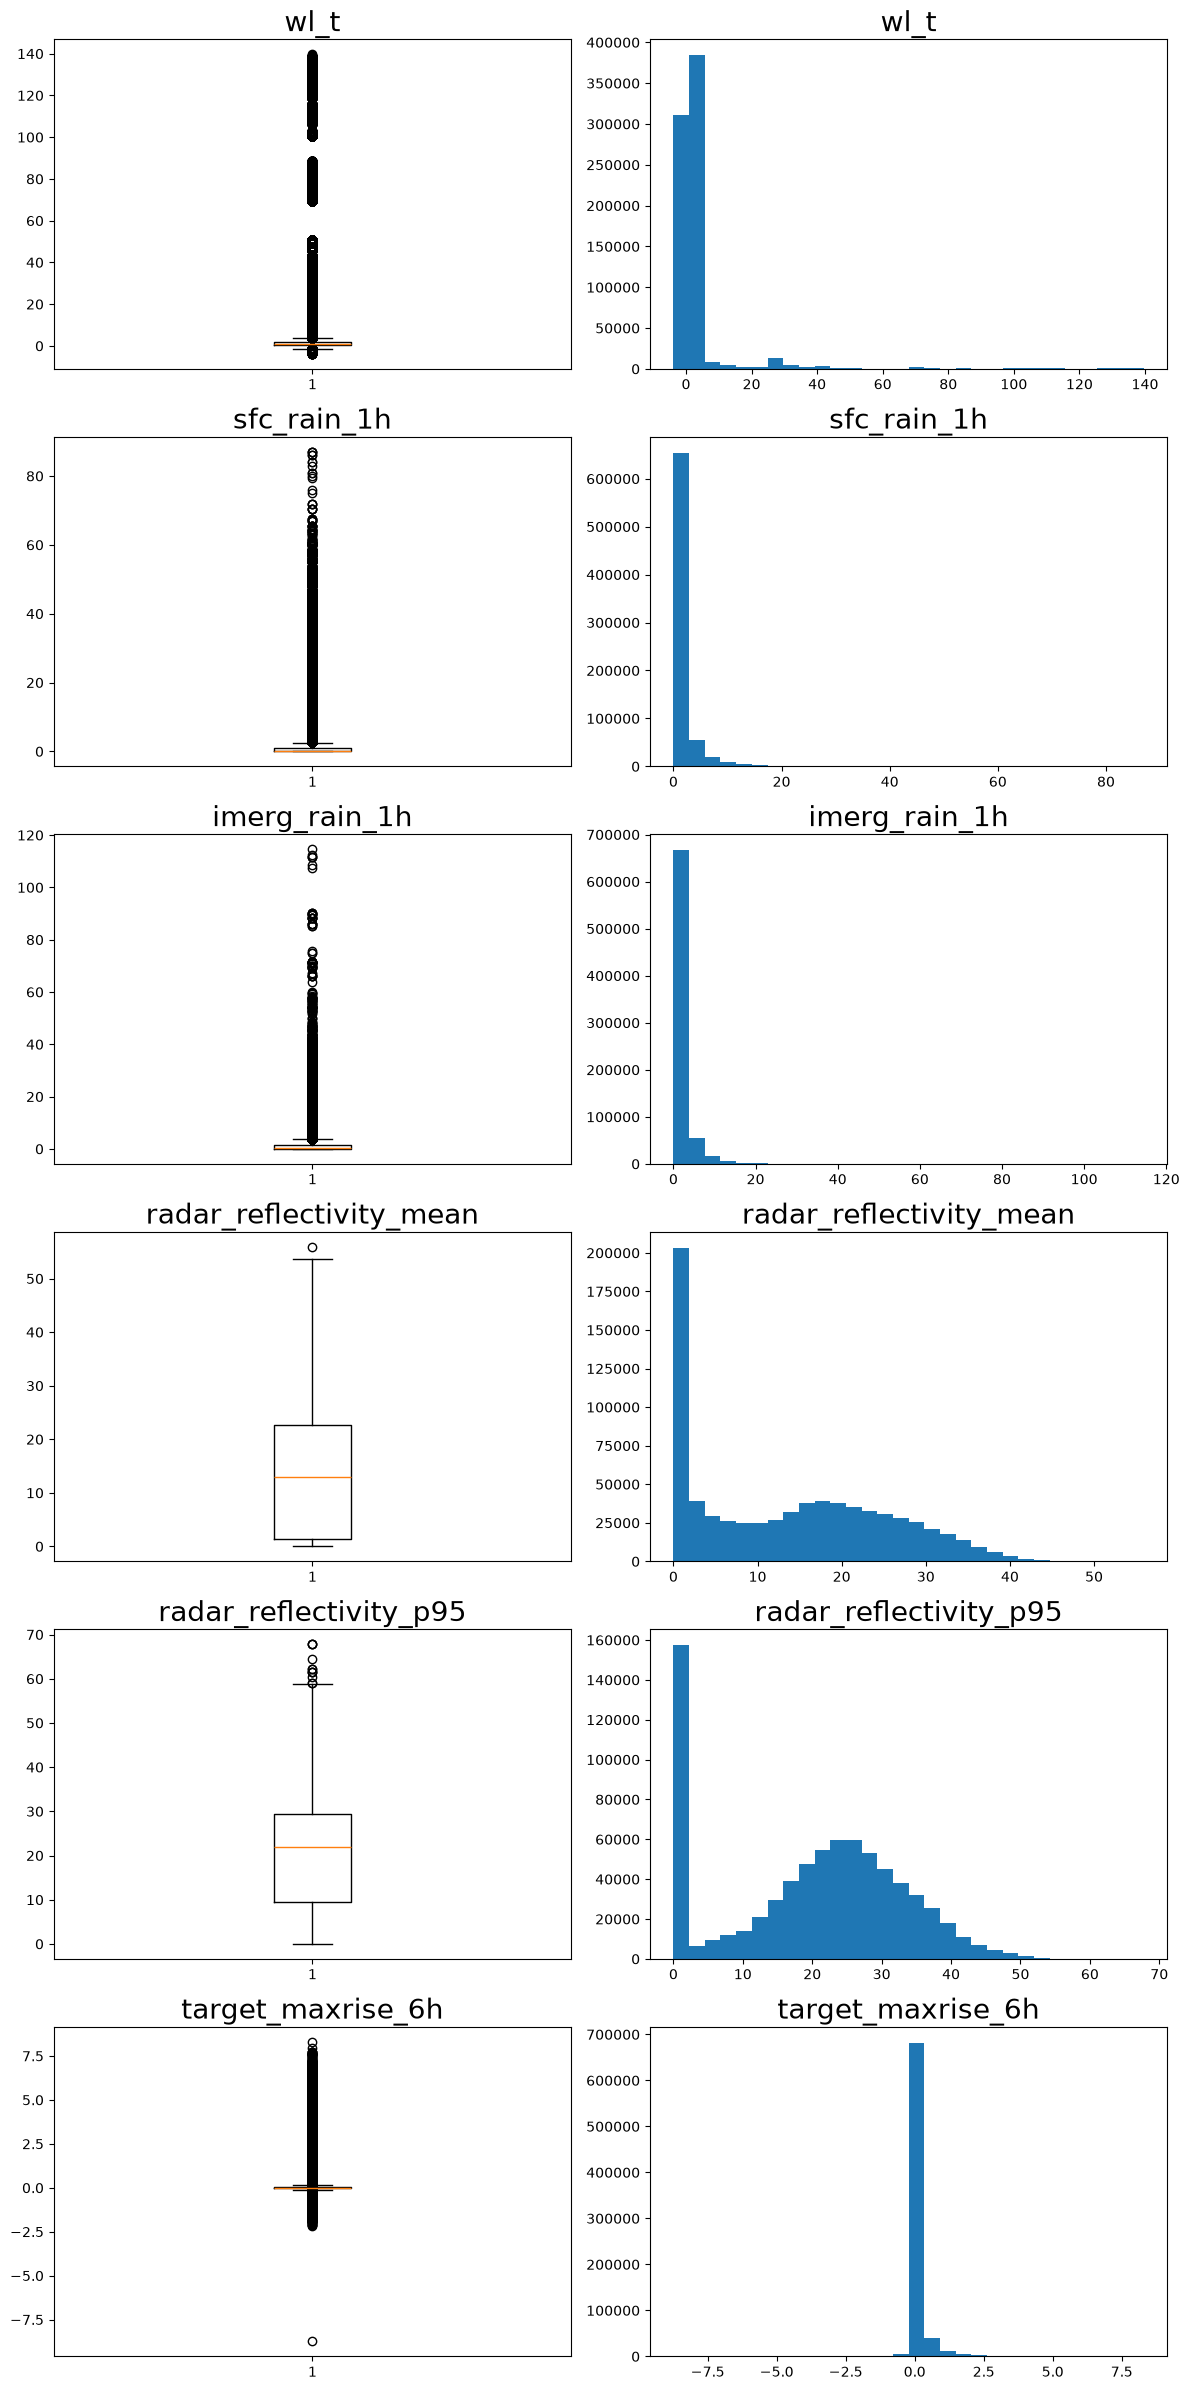

In [ ]:
# ============================================================
# 2. EDA: 구조확인(박스플롯, 히스토그램)
# ============================================================

# 2-1. 시계열데이터 EDA(데이터 그대로)
# 시계열데이터는 전체 데이터에 대해, 환경데이터는 관측소별로 groupby 한 후에 EDA 진행

# 시계열데이터 박스플롯과 히스토그램 그리기

import matplotlib.pyplot as plt

fig, axes = plt.subplots( # 반환객체 두가지: fig는 전체 도화지, axes는 내부배열
    len(time_cols),   # 행 개수
    2,           # 열 개수
    figsize = (12, 4 * len(time_cols))) # 전체 크기(가로×세로, 인치) 튜플로 넣기
# 기본적으로 열 개수가 2이므로 axes는 한 행당 두개의 ax를 반환

if len(time_cols) == 1: # cols에 한개 열만 오면 axes = [ax1, ax2...]만 반환
    axes = [axes]  # axes = [[ax1, ax2]]가 돼야 행열(0행 0, 1열) 접근이 가능

for i, col in enumerate(time_cols):
    x = df[col].dropna()  # 플롯을 여러개 그릴 예정, 플롯할 데이터를 하나의 변수로 묶어놓기(col임을 주의)

    axes[i][0].boxplot(x)
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)  # tick은 눈금을 의미, tick_params는 눈금설정값
    
    axes[i][1].hist(x, bins = 30)  # bins는 x축을 나눌 구간 개수
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)

plt.tight_layout()  # 자동 간격조정(배치관리)
plt.show()


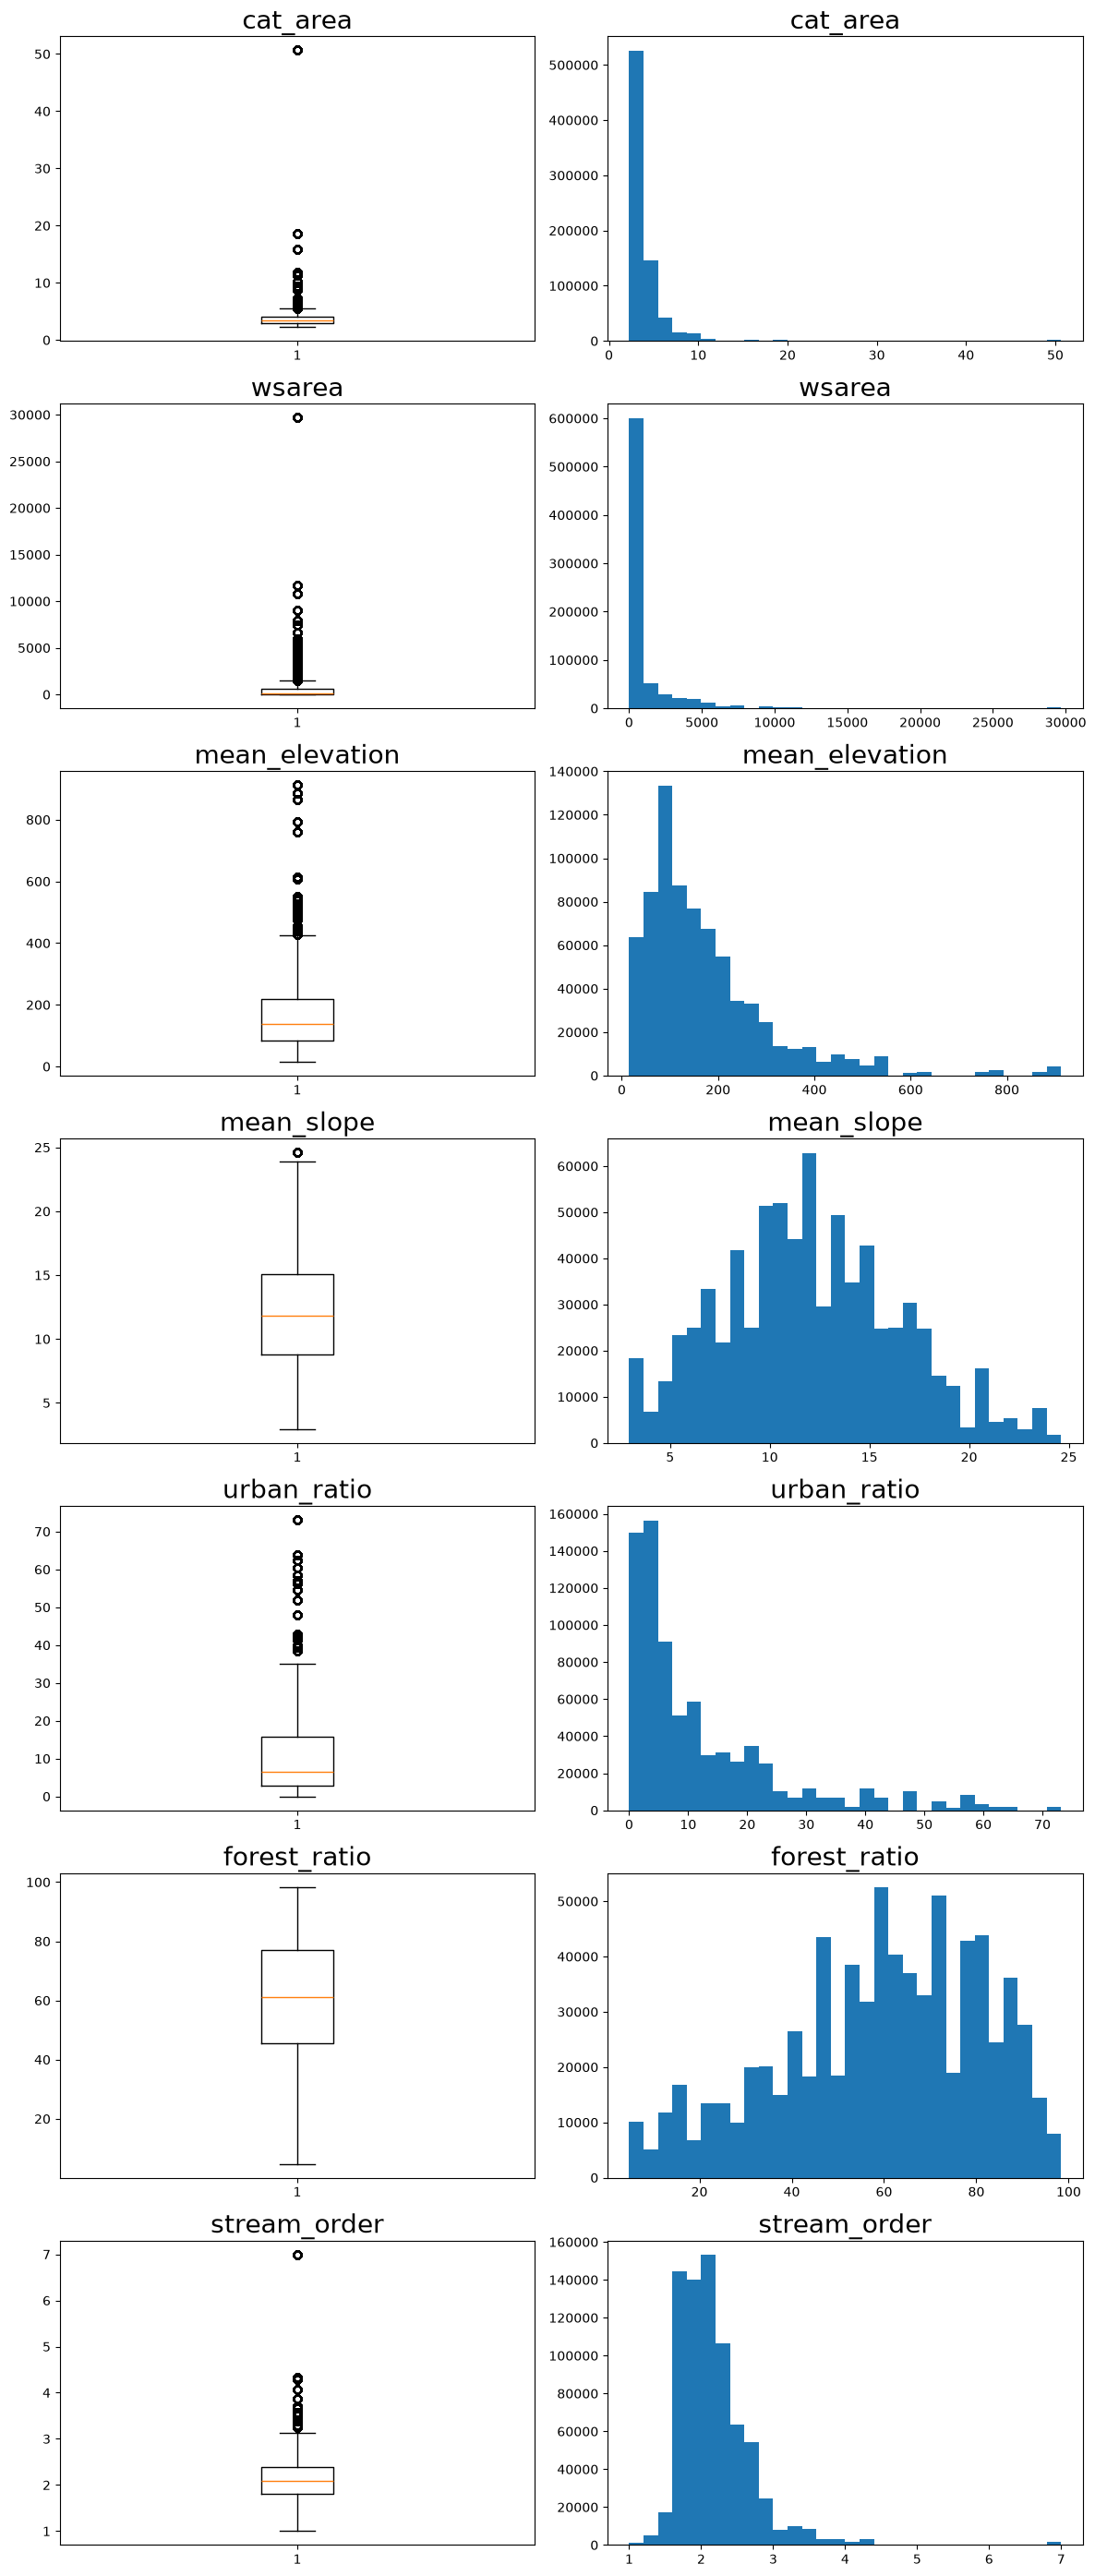

In [6]:
# 2-2. 환경데이터 EDA(관측소별 groupby, 관측소별 1개 값으로 EDA)

env_gb = df.groupby('station_id')[env_cols]
# print(env_gb.nunique().max()) 
# nunique()가 1이면 고유값, max() 결과 1보다 크면 같은 관측소 다른 데이터가 있다는 것
# 결과 모두 1 확인
# first(): 첫값만 꺼내기, 동일그룹 내 첫 값(동일값 중 대표)
env_gb_df = env_gb.first()
env_gb_df

# 이제 이걸로 EDA를 한다.
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    len(env_cols),
        2,
        figsize = (12, 4 * len(env_cols))
)

if len(env_cols) == 1:
    axes = [axes]

for i, col in enumerate(env_cols):
    x = df[col].dropna()

    axes[i][0].boxplot(x)
    axes[i][0].set_title(col, fontsize = 20)
    axes[i][0].tick_params(labelsize = 10)

    axes[i][1].hist(x, bins = 30)
    axes[i][1].set_title(col, fontsize = 20)
    axes[i][1].tick_params(labelsize = 10)

    
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 3. EDA: 구조확인(최대, 최소값)
# ============================================================

# 시계열데이터 중에 수위와 강수데이터는 여러가지가 섞여있음
# 왜도나 중앙값, 평균은 비슷하지만 이상치는 개별적으로 확인이 필요함
# describe 함수의 일부를 불러오고자 함

# print(df_describe)
print(
    df_describe[wl_cols_EDA]
    .loc[['max', 'min']]
    .to_csv(sep = '\t')
)

print(
    df_describe[rain_cols]
    .loc[['max', 'min']]
    .to_csv(sep = '\t')
)

	wl_t	wl_t_minus_1h	wl_t_minus_3h	wl_t_minus_6h	wl_t_minus_12h	wl_t_minus_24h	target_maxrise_6h
max	139.64	139.69	139.75	139.9	140.14	140.58	8.3
min	-3.84	-3.9	-3.9	-3.81	-3.91	-3.9	-8.74

	imerg_rain_1h	imerg_rain_6h	imerg_rain_24h	sfc_rain_1h	sfc_rain_6h	sfc_rain_24h	radar_reflectivity_mean	radar_reflectivity_p95	radar_reflectivity_ge20_fraction
max	114.53	313.557	371.228	87.0	290.5	390.0	55.917	67.77	1.0
min	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0



In [8]:
# ============================================================
# 4. 데이터 품질 확인
# ============================================================
# - 중복 데이터 확인: 0_file_loading 단계에서 index 고유성확인 완료
# - 결측치 개수 및 비율 확인
missing = df.isnull().sum()  # 크기순으로 정렬하려면 sort_values(ascending = True 추가)
print(missing)

# - 이상치 후보 확인


timestamp                           0
station_id                          0
wl_t                                0
wl_t_minus_1h                       0
wl_t_minus_3h                       0
wl_t_minus_6h                       0
wl_t_minus_12h                      0
wl_t_minus_24h                      0
imerg_rain_1h                       0
imerg_rain_6h                       0
imerg_rain_24h                      0
sfc_rain_1h                         0
sfc_rain_6h                         0
sfc_rain_24h                        0
radar_reflectivity_mean             0
radar_reflectivity_p95              0
radar_reflectivity_ge20_fraction    0
cat_area                            0
wsarea                              0
mean_elevation                      0
mean_slope                          0
urban_ratio                         0
forest_ratio                        0
stream_order                        0
target_maxrise_6h                   0
dtype: int64
